In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
dataset = pd.read_csv(r"C:\Users\SriniAchuthan\OneDrive\Desktop\Machine-Learning-A-Z-Codes-Datasets\Machine Learning A-Z\Part 6 - Reinforcement Learning\Section 32 - Upper Confidence Bound (UCB)\Python\Ads_CTR_Optimisation.csv")
print(dataset)

      Ad 1  Ad 2  Ad 3  Ad 4  Ad 5  Ad 6  Ad 7  Ad 8  Ad 9  Ad 10
0        1     0     0     0     1     0     0     0     1      0
1        0     0     0     0     0     0     0     0     1      0
2        0     0     0     0     0     0     0     0     0      0
3        0     1     0     0     0     0     0     1     0      0
4        0     0     0     0     0     0     0     0     0      0
...    ...   ...   ...   ...   ...   ...   ...   ...   ...    ...
9995     0     0     1     0     0     0     0     1     0      0
9996     0     0     0     0     0     0     0     0     0      0
9997     0     0     0     0     0     0     0     0     0      0
9998     1     0     0     0     0     0     0     1     0      0
9999     0     1     0     0     0     0     0     0     0      0

[10000 rows x 10 columns]


Total Clicks: 12387
Ad  1: shown 10000x | clicks=1703 | CTR=0.170
Ad  2: shown 10000x | clicks=1295 | CTR=0.130
Ad  3: shown 10000x | clicks= 728 | CTR=0.073
Ad  4: shown 10000x | clicks=1196 | CTR=0.120
Ad  5: shown 10000x | clicks=2695 | CTR=0.270
Ad  6: shown 10000x | clicks= 126 | CTR=0.013
Ad  7: shown 10000x | clicks=1112 | CTR=0.111
Ad  8: shown 10000x | clicks=2091 | CTR=0.209
Ad  9: shown 10000x | clicks= 952 | CTR=0.095
Ad 10: shown 10000x | clicks= 489 | CTR=0.049

Best Ad: Ad 1


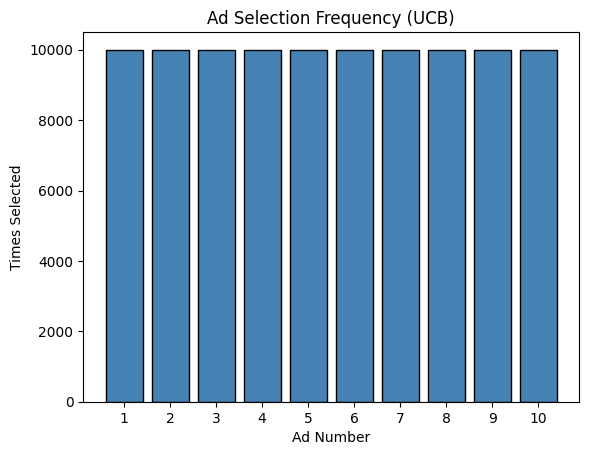

In [21]:
N = len(dataset)
d = len(dataset.columns)

N_Selected = [0] * d
sum_rewards = [0] * d
ads_selected = []
total_reward = 0

for n in range(N):
    for i in range(d):
        ad = 0
        max_ucb = -float('inf')
        if N_Selected[i] == 0:
            ucb_value = float('inf')

        else:
             avg_reward = sum_rewards[i] / N_Selected[i]
             confidence = math.sqrt(2 * math.log(n + 1) / N_Selected[i])
             ucb_value  = avg_reward + confidence


        if ucb_value > max_ucb:
              max_ucb = ucb_value
              ad = i

        ads_selected.append(ad)
        reward = dataset.values[n, ad]
        N_Selected[ad]  += 1
        sum_rewards[ad] += reward
        total_reward    += reward

  # Results
print(f'Total Clicks: {total_reward}')
for i in range(d):
    rate = sum_rewards[i] / N_Selected[i] if N_Selected[i] > 0 else 0
    print(f'Ad {i+1:2}: shown {N_Selected[i]:5}x | clicks={sum_rewards[i]:4} | CTR={rate:.3f}')

print(f'\nBest Ad: Ad {np.argmax(N_Selected)+1}')

  # Plot
plt.bar(range(1, d+1), N_Selected, color='steelblue', edgecolor='black')
plt.title('Ad Selection Frequency (UCB)')
plt.xlabel('Ad Number')
plt.ylabel('Times Selected')
plt.xticks(range(1, d+1))
plt.show()


